## This notebook creates a map showing number of occurrences of a selected species downloaded from OBIS at 0.5 x 0.5 degree hexagons. 

### Unzip the downloaded occurrence data file and create a data frame 'df' for processing. This cell takes 7 hours to run with the 'copepoda' zip file containing global data. SKIP THIS CELL AND USE THE .CSV FILE

In [ ]:
import os
import zipfile
import pandas as pd

# Define the working directory and file paths
base_dir = "/Users/enrique.montes/Documents/obis_mapper"
zip_file_name = "6210e262-4362-43eb-a1da-f45fffda3436.zip"
zip_path = os.path.join(base_dir, zip_file_name)

# Change the current working directory to your project folder
os.chdir(base_dir)
print(f"Working directory set to: {os.getcwd()}")

# Find the .tsv file inside the zip archive and load it directly
with zipfile.ZipFile(zip_path, 'r') as z:
    # List all files in the zip to find the name of the .tsv file
    file_list = z.namelist()
    tsv_filename = [f for f in file_list if f.endswith('.tsv')][0]
    
    print(f"Extracting and loading: {tsv_filename}...")
    
    # Open and read the TSV file directly into a pandas DataFrame
    with z.open(tsv_filename) as f:
        # OBIS TSV files use tab delimiters and are typically UTF-8 encoded
        df = pd.read_csv(f, sep='\t', low_memory=False)

# Display basic information about the loaded dataset
print(f"Successfully loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

### Processed the extracted data frame 'df' to bin occurrences with 0.5 x 0.5 degree cells. This cell creates the .CSV file stored here. SKIP THIS CELL AND USE THE .CSV FILE

In [ ]:
import numpy as np

# 1. Define the target taxonomic filters
# Changing these variables allows the notebook to work for any taxon
target_rank = 'class'
target_name = 'Copepoda'

# Filter the dataframe dynamically
species_df = df[df[target_rank].str.lower() == target_name.lower()].copy()

# 2. Define the grid size (0.5 degrees)
grid_size = 0.5

# 3. Bin the coordinates
# We use np.floor to find the lower bound of the grid cell, 
# then add grid_size/2 to get the center point of the 0.5x0.5 degree bin.
species_df['grid_lon'] = np.floor(species_df['decimalLongitude'] / grid_size) * grid_size + (grid_size / 2)
species_df['grid_lat'] = np.floor(species_df['decimalLatitude'] / grid_size) * grid_size + (grid_size / 2)

# 4. Group by the grid cells and aggregate by counting occurrences
grid_df = (
    species_df.groupby(['grid_lon', 'grid_lat'])
    .size()
    .reset_index(name='occurrence_count')
)

# 5. Sort by density so the highest density areas are easy to spot
grid_df = grid_df.sort_values(by='occurrence_count', ascending=False).reset_index(drop=True)

# Display basic information about the aggregated grid
print(f"Aggregated data into {grid_df.shape[0]:,} unique 0.5x0.5 degree grid cells.")
print(f"Maximum occurrences in a single cell: {grid_df['occurrence_count'].max():,}")

# Save the aggregated grid to a CSV file for future use
grid_df.to_csv('copepoda_occurrence_grid.csv', index=False)
print("Saved aggregated grid to 'copepoda_occurrence_grid.csv'")

# Preview the aggregated dataframe
grid_df.head()

### Create the map

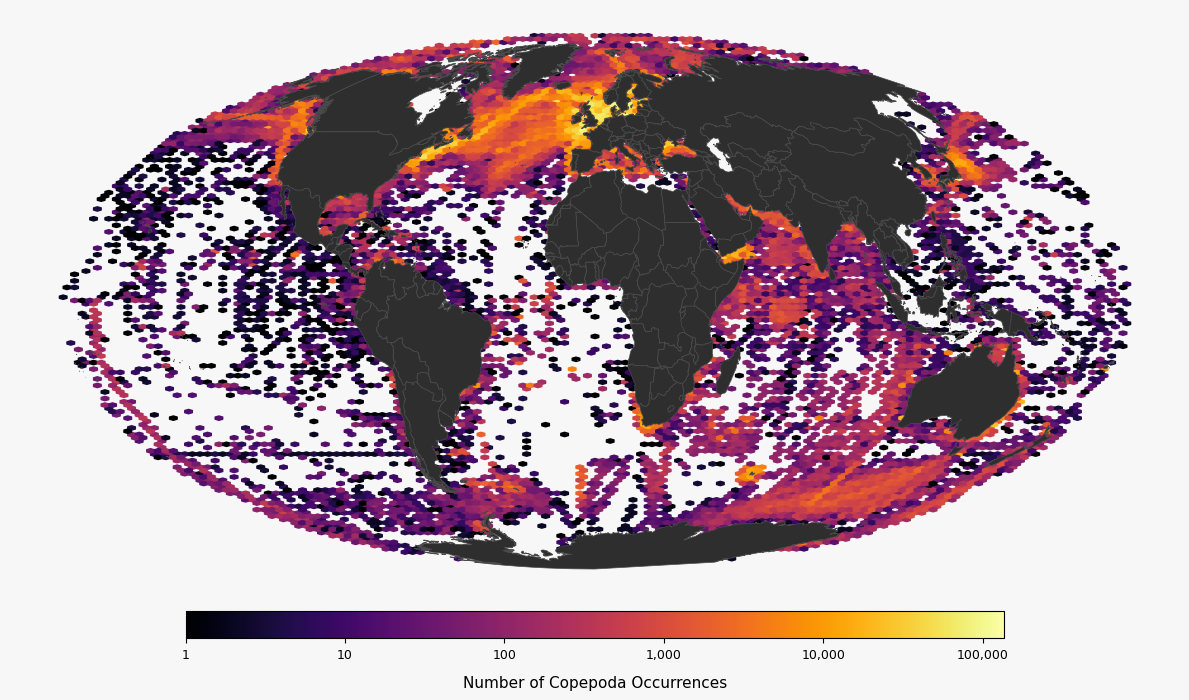

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

grid_df = pd.read_csv('copepoda_occurrence_grid.csv')

# Define the target taxonomic filters
# Changing these variables allows the notebook to work for any taxon
target_rank = 'class'
target_name = 'Copepoda'

# 1. Convert our pandas dataframe into a GeoDataFrame of points
geometry = [Point(xy) for xy in zip(grid_df['grid_lon'], grid_df['grid_lat'])]
gdf = gpd.GeoDataFrame(grid_df, geometry=geometry, crs="EPSG:4326")

# 2. Reproject the points to the Mollweide projection (ESRI:54009) to create the oval layout
mollweide_crs = "+proj=moll +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
gdf_projected = gdf.to_crs(mollweide_crs)

# 3. Stream a clean world coastline dataset directly from the web
world_url = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson"
world = gpd.read_file(world_url)
world_projected = world.to_crs(mollweide_crs)

# 4. Generate the plot axis frame with explicit figure adjustments
fig, ax = plt.subplots(figsize=(12, 8))

# Set a clean light background for the ocean space
ax.set_facecolor('#f7f7f7') 
fig.patch.set_facecolor('#f7f7f7')

# 5. Calculate log10 values for color scaling (Data Layer: Lower zorder)
hb = ax.hexbin(
    gdf_projected.geometry.x, 
    gdf_projected.geometry.y, 
    C=gdf_projected['occurrence_count'], 
    reduce_C_function=lambda x: np.log10(np.sum(x)),  # Log-transform the sum of records per hex
    gridsize=140,          
    cmap='inferno',       
    mincnt=1,             
    zorder=2               # Hexagons are drawn on layer 2
)

# 6. Draw the world landmasses in Dark Gray OVER the data layer (Masking Layer: Higher zorder)
# Moving this below the hexbin step ensures it stays on top of any overlapping hexagons.
world_projected.plot(ax=ax, color='#2e2e2e', edgecolor='#4a4a4a', linewidth=0.5, zorder=3)

# 7. Add a highly visible, explicitly positioned color bar
cb = fig.colorbar(
    hb, 
    ax=ax, 
    orientation='horizontal', 
    pad=0.02, 
    shrink=0.7, 
    aspect=30
)

# Force the colorbar ticks to step cleanly by integer log values (1, 10, 100, 1000...)
cb.locator = ticker.MaxNLocator(integer=True)
cb.update_ticks()

# Format log values back into readable count labels (e.g., 0 -> 1, 1 -> 10, 2 -> 100)
cb.ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(10**x):,}"))

# Style the color bar label text
cb.set_label(f'Number of {target_name} Occurrences', fontsize=11, fontweight='medium', labelpad=10)
cb.ax.tick_params(labelsize=9)

# Strip out unnecessary outer bounding grid lines
ax.set_axis_off()

# plt.title(f"Global Aggregated Hexbin Map of {target_name} (Logarithmic Scale)", fontsize=14, pad=15)

# Tight layout guarantees nothing gets clipped outside the canvas window
plt.tight_layout()
plt.show()